<a href="https://colab.research.google.com/github/LeonardoFisAct/DSML_Notes/blob/main/Final_Activity_ModuleII.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Importar las librerias necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Entorno Sklearn
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, recall_score
from sklearn.model_selection import GridSearchCV

# Boosting
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import HistGradientBoostingClassifier

# LightGBM
import lightgbm as lgb

In [ ]:
df = pd.read_csv("personality_dataset_desbalanceado.csv")

# EDA

Este data set es un conjunto de observaciones relacionadas con la personalidad de una persona. (target: `Personality`)

Variables Predcitoras:

`Time_spent_Alone` : el tiempo que pasa en soledad

`Stage_fear` : Miedo a hablar en publico

`Social_event_attendance` : Número de eventos sociales a los que asistio.

`Going_outside` : Número de veces que salio de paseo

`Drained_after_socializing` : Cansancio despues de socializar

`Friends_circle_size` : Número de amigos en su circulo social

`Post_frecuency` : Frecuencia con la que realiza publicaciones en redes sociales.

In [ ]:
df.head()

,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
0,4.0,No,4.0,6.0,No,13.0,5.0,Extrovert
1,9.0,Yes,0.0,0.0,Yes,0.0,3.0,Introvert
2,9.0,Yes,1.0,2.0,Yes,5.0,2.0,Introvert
3,0.0,No,6.0,7.0,No,14.0,8.0,Extrovert
4,3.0,No,9.0,4.0,No,8.0,5.0,Extrovert


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1474 entries, 0 to 1473
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Time_spent_Alone           1443 non-null   float64
 1   Stage_fear                 1442 non-null   object 
 2   Social_event_attendance    1439 non-null   float64
 3   Going_outside              1441 non-null   float64
 4   Drained_after_socializing  1440 non-null   object 
 5   Friends_circle_size        1436 non-null   float64
 6   Post_frequency             1442 non-null   float64
 7   Personality                1474 non-null   object 
dtypes: float64(5), object(3)
memory usage: 92.3+ KB


In [ ]:
df.isna().sum()

,0
Time_spent_Alone,31
Stage_fear,32
Social_event_attendance,35
Going_outside,33
Drained_after_socializing,34
Friends_circle_size,38
Post_frequency,32
Personality,0


Distribución de clases:
Personality
Introvert    0.955902
Extrovert    0.044098
Name: proportion, dtype: float64


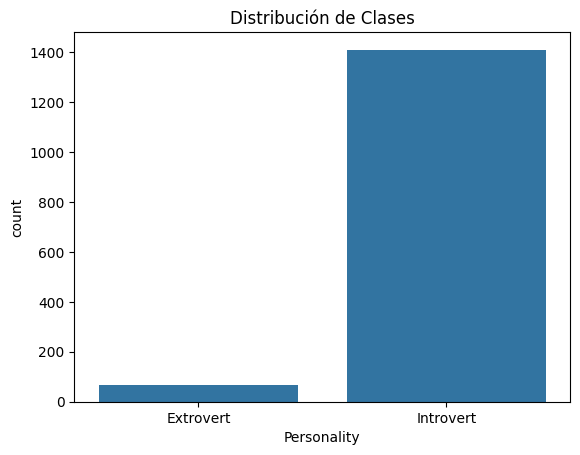

In [ ]:
# Balance de clases
print("Distribución de clases:")
print(df['Personality'].value_counts(normalize=True))

sns.countplot(x='Personality', data=df)
plt.title('Distribución de Clases')
plt.show()

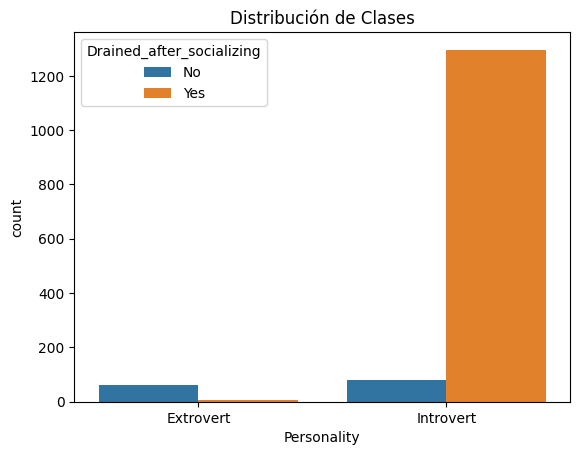

In [ ]:
sns.countplot(x='Personality',hue='Drained_after_socializing', data=df)
plt.title('Distribución de Clases')
plt.show()

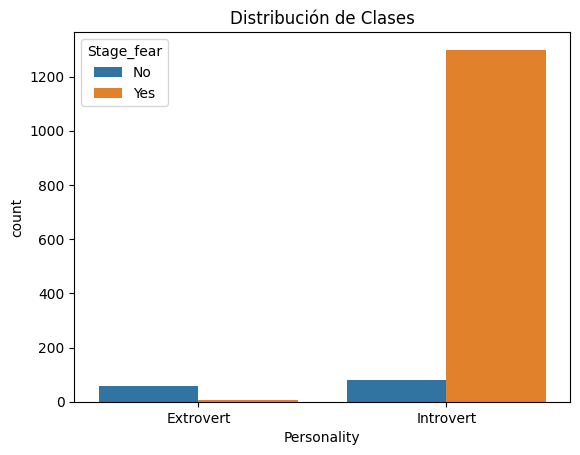

In [ ]:
sns.countplot(x='Personality',hue='Stage_fear', data=df)
plt.title('Distribución de Clases')
plt.show()

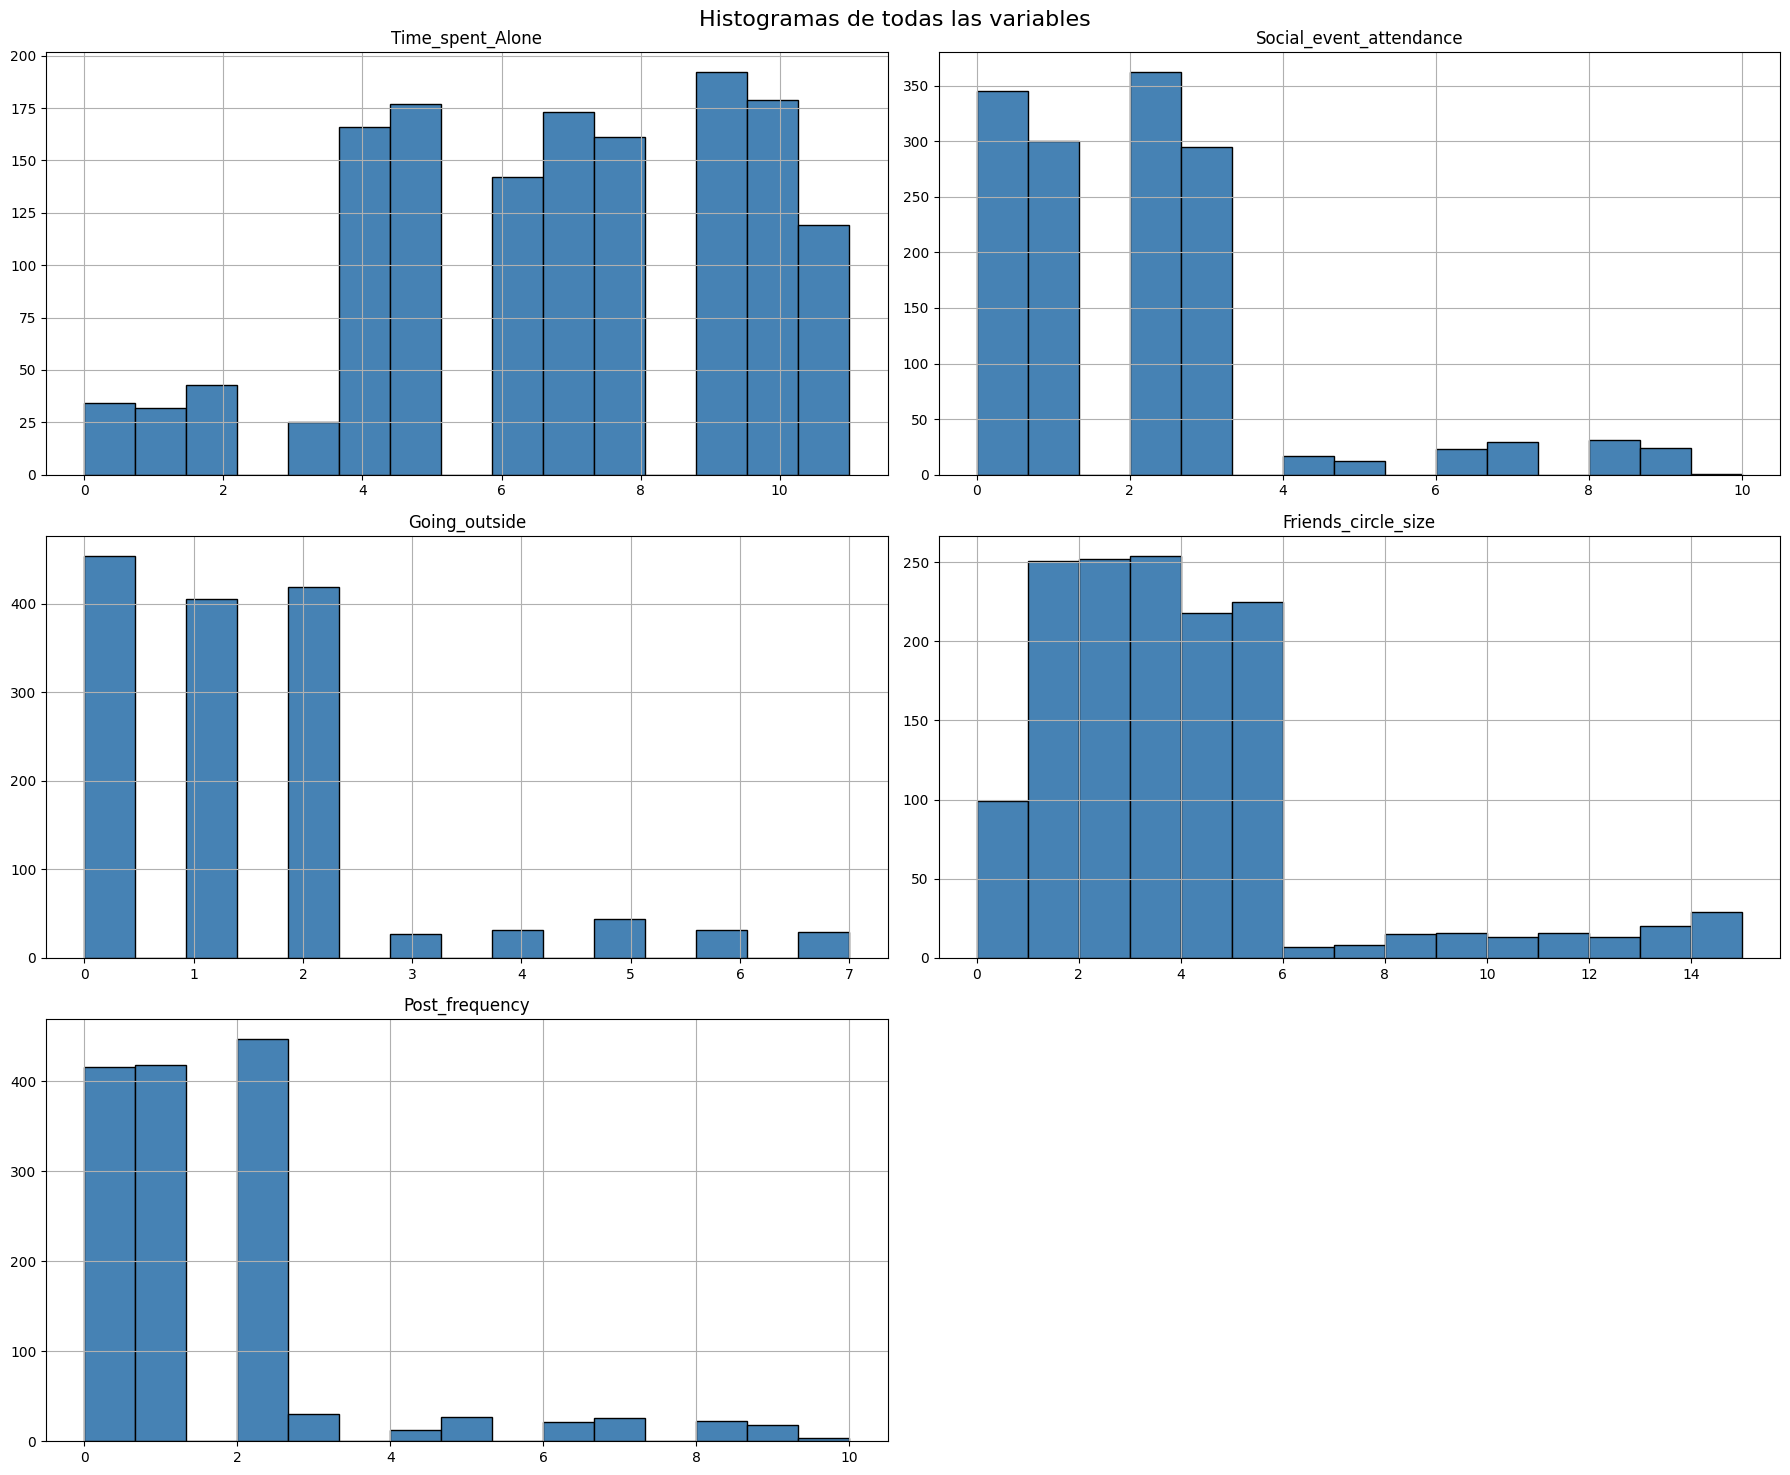

In [ ]:
# Histograma para todas las variables Numericas
df.drop(columns=['Personality','Drained_after_socializing', 'Stage_fear']).hist(bins=15, figsize=(18, 15), color='steelblue', edgecolor='black')
plt.suptitle("Histogramas de todas las variables", fontsize=16)
plt.tight_layout()
plt.show()


Se pueden observar una distribución uniforme en la mayoria de las variables con unos cuantos outliers, lo cual es intuitivo dado el desbalanceo de la variable objetivo.

Como son valores enteros imputar los valores faltantes, que son pocos, con la media no seria lo mas adecuado asi que se realizara la imputación con la moda. Lo mismo para las variables categoricas.

Al tener todas las variables en la misma escala, no es necesario escalar los datos. Ya que no existen valores grandes que pudieran afectar el desempeño del arbol de clasificación.

En cuanto al desbalanceo se utlizara el parámetro `class_weight = balanced `, para mejorar el recall de la clasificación.

# Preprocesamiento

In [ ]:
#Imputación de las variables
df.fillna(df.mode().iloc[0], inplace=True)
df.isna().sum()

,0
Time_spent_Alone,0
Stage_fear,0
Social_event_attendance,0
Going_outside,0
Drained_after_socializing,0
Friends_circle_size,0
Post_frequency,0
Personality,0


In [ ]:
map = {"Yes":0, "No":1}
df['Drained_after_socializing'] = df['Drained_after_socializing'].map(map)
df['Stage_fear'] = df['Stage_fear'].map(map)
#df.head()

X = df.drop(columns=['Personality'])
y = df['Personality']

In [ ]:
# División de datos
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

#Entrenamiento

In [ ]:
# Entrenamiento y evaluación con class_weight='balanced'

# Árbol de decisión ponderado
tree_clf_bal = DecisionTreeClassifier(max_depth=4, class_weight='balanced', random_state=42)
tree_clf_bal.fit(X_train, y_train)

# Random Forest ponderado
rf_clf_bal = RandomForestClassifier(n_estimators=100, max_depth=4, class_weight='balanced', random_state=42)
rf_clf_bal.fit(X_train, y_train)

# Predicciones
y_pred_tree_bal = tree_clf_bal.predict(X_test)
y_pred_rf_bal = rf_clf_bal.predict(X_test)

# Reportes de clasificación
report_tree_bal = pd.DataFrame(classification_report(y_test, y_pred_tree_bal, output_dict=True)).transpose().round(3)
report_rf_bal = pd.DataFrame(classification_report(y_test, y_pred_rf_bal, output_dict=True)).transpose().round(3)

# Matrices de confusión
conf_df_tree_bal = pd.DataFrame(
    confusion_matrix(y_test, y_pred_tree_bal),
    index=["Real 0 (Extrovetido)", "Real 1 (Introvertido)"],
    columns=["Predicho 0", "Predicho 1"]
)

conf_df_rf_bal = pd.DataFrame(
    confusion_matrix(y_test, y_pred_rf_bal),
    index=["Real 0 (Extrovertido)", "Real 1 (Introvertido)"],
    columns=["Predicho 0", "Predicho 1"]
)

# Mostrar resultados
report_tree_bal, conf_df_tree_bal, report_rf_bal, conf_df_rf_bal

(              precision  recall  f1-score  support
 Extrovert         0.293   0.850     0.436   20.000
 Introvert         0.992   0.903     0.946  423.000
 accuracy          0.901   0.901     0.901    0.901
 macro avg         0.643   0.877     0.691  443.000
 weighted avg      0.961   0.901     0.923  443.000,
                        Predicho 0  Predicho 1
 Real 0 (Extrovetido)           17           3
 Real 1 (Introvertido)          41         382,
               precision  recall  f1-score  support
 Extrovert         0.395   0.850     0.540   20.000
 Introvert         0.992   0.939     0.965  423.000
 accuracy          0.935   0.935     0.935    0.935
 macro avg         0.694   0.894     0.752  443.000
 weighted avg      0.966   0.935     0.946  443.000,
                        Predicho 0  Predicho 1
 Real 0 (Extrovertido)          17           3
 Real 1 (Introvertido)          26         397)

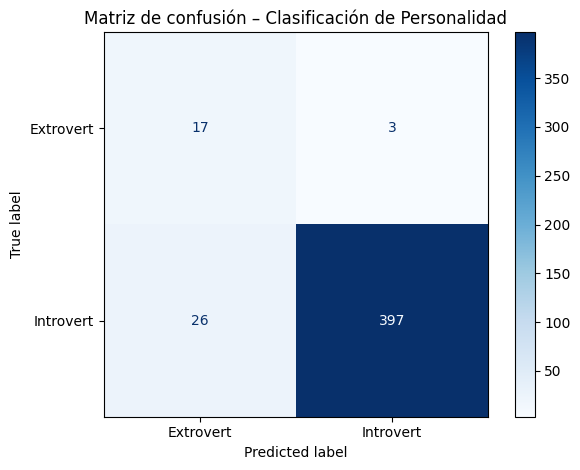

In [ ]:
# Matriz de confusión
ConfusionMatrixDisplay.from_estimator(rf_clf_bal, X_test, y_test, cmap="Blues")
plt.title("Matriz de confusión – Clasificación de Personalidad")
plt.tight_layout()
plt.show()

El algoritmo random forest nos da una mejor clasificación en comparación con un solo arbol,

Se muestra el arbol de decisión

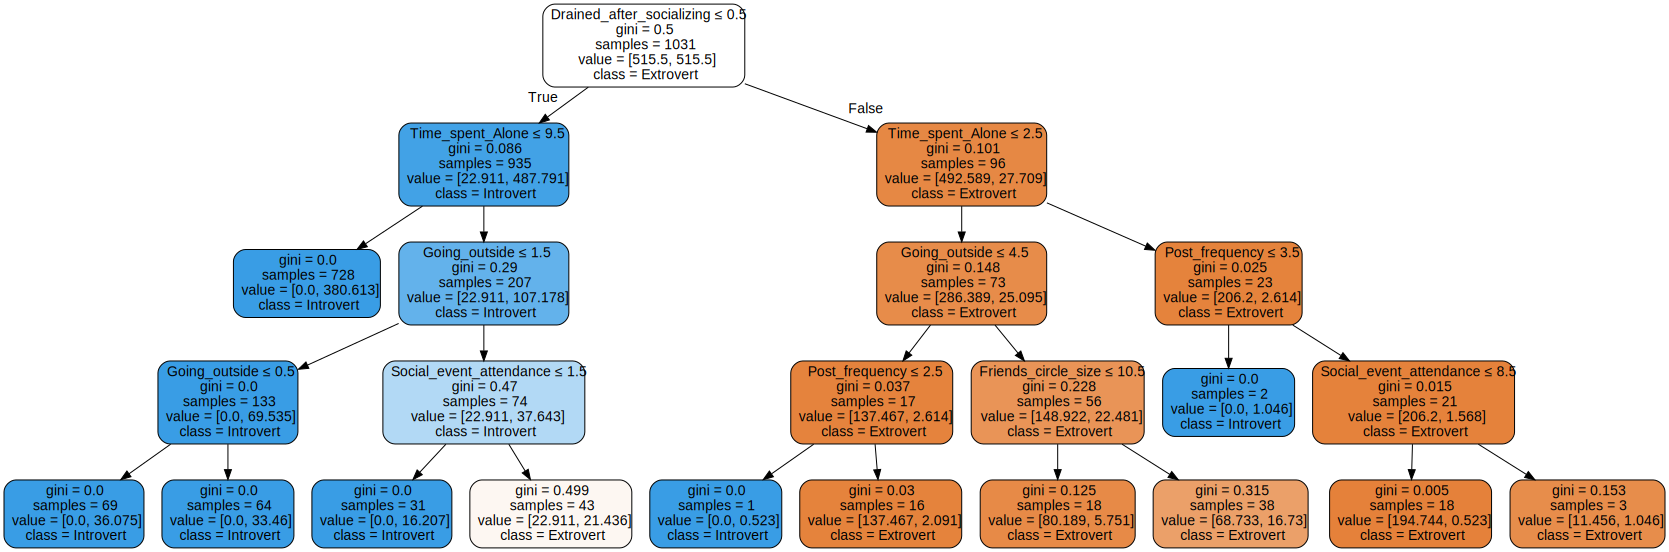

In [ ]:
from sklearn.tree import export_graphviz
from graphviz import Source

# Nombres de las variables
feature_names = X.columns.tolist()

# Nombres de las clases
class_names = y.unique().tolist()

# Exportar a formato DOT y visualizar con graphviz
dot_data = export_graphviz(
    tree_clf_bal,
    out_file=None,
    feature_names=feature_names,
    class_names=class_names,
    filled=True,
    rounded=True,
    special_characters=True
)

# Mostrar el árbol
Source(dot_data)

/tmp/ipykernel_2843/1862525393.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances_reg[indices_reg], y=features_reg[indices_reg], palette="Greens_d")


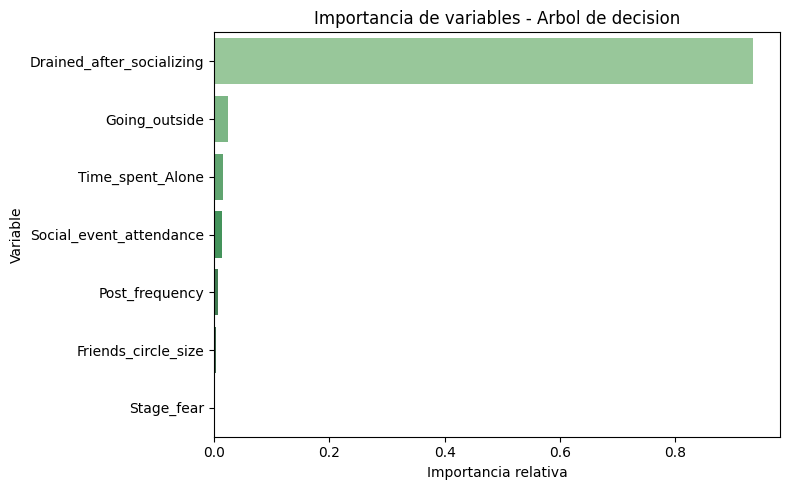

In [ ]:
# Importancia de variables - Regresión (California Housing)
importances_reg = tree_clf_bal.feature_importances_
features_reg = X.columns
indices_reg = np.argsort(importances_reg)[::-1]

plt.figure(figsize=(8, 5))
sns.barplot(x=importances_reg[indices_reg], y=features_reg[indices_reg], palette="Greens_d")
plt.title("Importancia de variables - Arbol de decision")
plt.xlabel("Importancia relativa")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()


Podemos notar que la variable mas importante para el arbol de clasificación es `Drainded_after_socialazing` esta al tener casi el mismo tamaño en ambas clases pudiera estar sesgando la decisión al hacer una incorrecta clasificiación.

In [ ]:
#Clasificacion sin esta variable
X_train_new = X_train.drop(columns=['Drained_after_socializing'])
X_test_new = X_test.drop(columns=['Drained_after_socializing'])
# Árbol de decisión ponderado
tree_clf_bal = DecisionTreeClassifier(max_depth=4, class_weight='balanced', random_state=42)
tree_clf_bal.fit(X_train_new, y_train)

# Random Forest ponderado
rf_clf_bal = RandomForestClassifier(n_estimators=100, max_depth=4, class_weight='balanced', random_state=42)
rf_clf_bal.fit(X_train_new, y_train)

# Predicciones
y_pred_tree_bal = tree_clf_bal.predict(X_test_new)
y_pred_rf_bal = rf_clf_bal.predict(X_test_new)

# Reportes de clasificación
report_tree_bal = pd.DataFrame(classification_report(y_test, y_pred_tree_bal, output_dict=True)).transpose().round(3)
report_rf_bal = pd.DataFrame(classification_report(y_test, y_pred_rf_bal, output_dict=True)).transpose().round(3)

# Matrices de confusión
conf_df_tree_bal = pd.DataFrame(
    confusion_matrix(y_test, y_pred_tree_bal),
    index=["Real 0 (Extrovetido)", "Real 1 (Introvertido)"],
    columns=["Predicho 0", "Predicho 1"]
)

conf_df_rf_bal = pd.DataFrame(
    confusion_matrix(y_test, y_pred_rf_bal),
    index=["Real 0 (Extrovertido)", "Real 1 (Introvertido)"],
    columns=["Predicho 0", "Predicho 1"]
)

# Mostrar resultados
report_tree_bal, conf_df_tree_bal, report_rf_bal, conf_df_rf_bal

(              precision  recall  f1-score  support
 Extrovert         0.274   0.850     0.415   20.000
 Introvert         0.992   0.894     0.940  423.000
 accuracy          0.892   0.892     0.892    0.892
 macro avg         0.633   0.872     0.677  443.000
 weighted avg      0.960   0.892     0.917  443.000,
                        Predicho 0  Predicho 1
 Real 0 (Extrovetido)           17           3
 Real 1 (Introvertido)          45         378,
               precision  recall  f1-score  support
 Extrovert         0.395   0.850     0.540   20.000
 Introvert         0.992   0.939     0.965  423.000
 accuracy          0.935   0.935     0.935    0.935
 macro avg         0.694   0.894     0.752  443.000
 weighted avg      0.966   0.935     0.946  443.000,
                        Predicho 0  Predicho 1
 Real 0 (Extrovertido)          17           3
 Real 1 (Introvertido)          26         397)

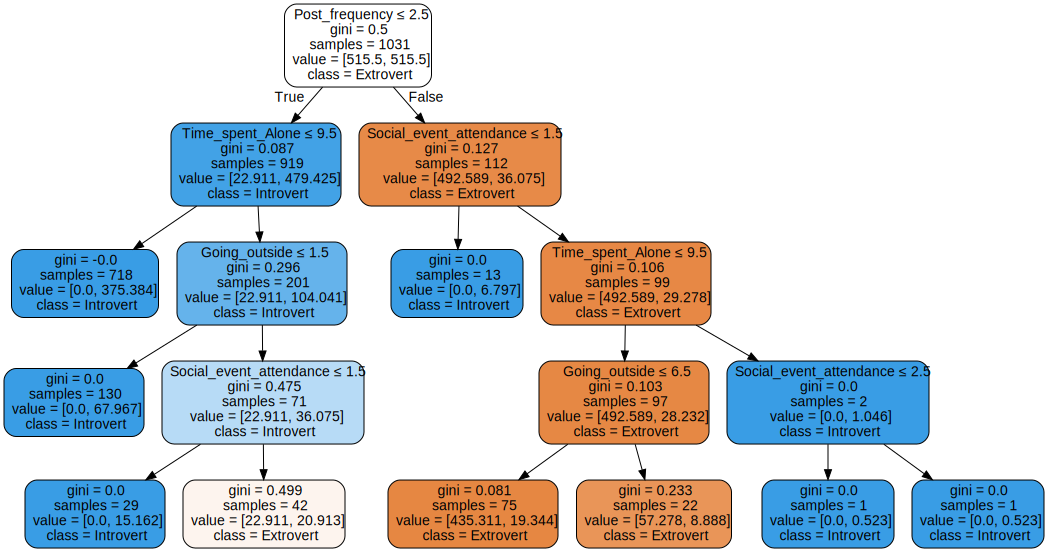

In [ ]:
from sklearn.tree import export_graphviz
from graphviz import Source

# Nombres de las variables
feature_names = X_train_new.columns.tolist()

# Nombres de las clases
class_names = y.unique().tolist()

# Exportar a formato DOT y visualizar con graphviz
dot_data = export_graphviz(
    tree_clf_bal,
    out_file=None,
    feature_names=feature_names,
    class_names=class_names,
    filled=True,
    rounded=True,
    special_characters=True
)

# Mostrar el árbol
Source(dot_data)

La clasificación empeora un poco en lugar de mejorar

# Cross-Validation

In [ ]:
#Modelo base
tree_clf_bal = DecisionTreeClassifier( class_weight='balanced', random_state=42)

# Definir la grilla de hiperparámetros
param_grid = {
    'max_depth': [ 3, 4, 5, 6, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Búsqueda de hiperparámetros con validación cruzada
grid_search = GridSearchCV(tree_clf_bal, param_grid, cv=5, scoring='recall', n_jobs=-1)
grid_search.fit(X_train, y_train)

# Mejor estimador y evaluación en conjunto de prueba
best_tree = grid_search.best_estimator_
y_pred = best_tree.predict(X_test)
mejor_accuracy = accuracy_score(y_test, y_pred)
mejor_params = grid_search.best_params_
informe = classification_report(y_test, y_pred, output_dict=True)

pd.DataFrame(informe).T, mejor_accuracy, mejor_params


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:1108: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan]
  warnings.warn(


(              precision    recall  f1-score     support
 Extrovert      0.395349  0.850000  0.539683   20.000000
 Introvert      0.992500  0.938534  0.964763  423.000000
 accuracy       0.934537  0.934537  0.934537    0.934537
 macro avg      0.693924  0.894267  0.752223  443.000000
 weighted avg   0.965541  0.934537  0.945572  443.000000,
 0.9345372460496614,
 {'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2})

In [ ]:
# Entrenamiento y evaluación con class_weight='balanced'

# Árbol de decisión ponderado
tree_clf_bal = DecisionTreeClassifier(max_depth=3, class_weight='balanced', random_state=42)
tree_clf_bal.fit(X_train, y_train)

# Random Forest ponderado
rf_clf_bal = RandomForestClassifier(n_estimators=100, max_depth=3, class_weight='balanced', random_state=42)
rf_clf_bal.fit(X_train, y_train)

# Predicciones
y_pred_tree_bal = tree_clf_bal.predict(X_test)
y_pred_rf_bal = rf_clf_bal.predict(X_test)

# Reportes de clasificación
report_tree_bal = pd.DataFrame(classification_report(y_test, y_pred_tree_bal, output_dict=True)).transpose().round(3)
report_rf_bal = pd.DataFrame(classification_report(y_test, y_pred_rf_bal, output_dict=True)).transpose().round(3)

# Matrices de confusión
conf_df_tree_bal = pd.DataFrame(
    confusion_matrix(y_test, y_pred_tree_bal),
    index=["Real 0 (Extrovetido)", "Real 1 (Introvertido)"],
    columns=["Predicho 0", "Predicho 1"]
)

conf_df_rf_bal = pd.DataFrame(
    confusion_matrix(y_test, y_pred_rf_bal),
    index=["Real 0 (Extrovertido)", "Real 1 (Introvertido)"],
    columns=["Predicho 0", "Predicho 1"]
)

# Mostrar resultados
report_tree_bal, conf_df_tree_bal, report_rf_bal, conf_df_rf_bal

(              precision  recall  f1-score  support
 Extrovert         0.395   0.850     0.540   20.000
 Introvert         0.992   0.939     0.965  423.000
 accuracy          0.935   0.935     0.935    0.935
 macro avg         0.694   0.894     0.752  443.000
 weighted avg      0.966   0.935     0.946  443.000,
                        Predicho 0  Predicho 1
 Real 0 (Extrovetido)           17           3
 Real 1 (Introvertido)          26         397,
               precision  recall  f1-score  support
 Extrovert         0.395   0.850     0.540   20.000
 Introvert         0.992   0.939     0.965  423.000
 accuracy          0.935   0.935     0.935    0.935
 macro avg         0.694   0.894     0.752  443.000
 weighted avg      0.966   0.935     0.946  443.000,
                        Predicho 0  Predicho 1
 Real 0 (Extrovertido)          17           3
 Real 1 (Introvertido)          26         397)

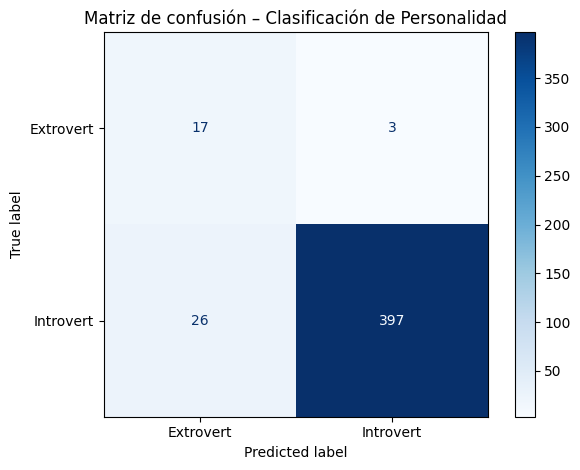

In [ ]:
# Matriz de confusión
ConfusionMatrixDisplay.from_estimator(tree_clf_bal, X_test, y_test, cmap="Blues")
plt.title("Matriz de confusión – Clasificación de Personalidad")
plt.tight_layout()
plt.show()

Con solo reducir la profundidad del arbol se observa una mejora significativa, los resultados obtenidos en la matriz de confusión son los mismos que al utilizar random forest. Pero aun clasifica de manera incorrecta una cantidad considerable de introvertidos como extrovertidos.

# Regularización

Se utilizaran Boosting para mejorar el poder predictivo del modelo.

## ADA

In [ ]:
# Árbol base (shallow stump)
base_tree = DecisionTreeClassifier(max_depth=3, class_weight='balanced')

# AdaBoost con 100 estimadores
ada = AdaBoostClassifier(
    estimator=base_tree,
    n_estimators=100,
    learning_rate=1.0,
    random_state=42
)
ada.fit(X_train, y_train)
y_pred_ada = ada.predict(X_test)

print(classification_report(y_test, y_pred_ada))

              precision    recall  f1-score   support

   Extrovert       0.37      0.75      0.49        20
   Introvert       0.99      0.94      0.96       423

    accuracy                           0.93       443
   macro avg       0.68      0.84      0.73       443
weighted avg       0.96      0.93      0.94       443



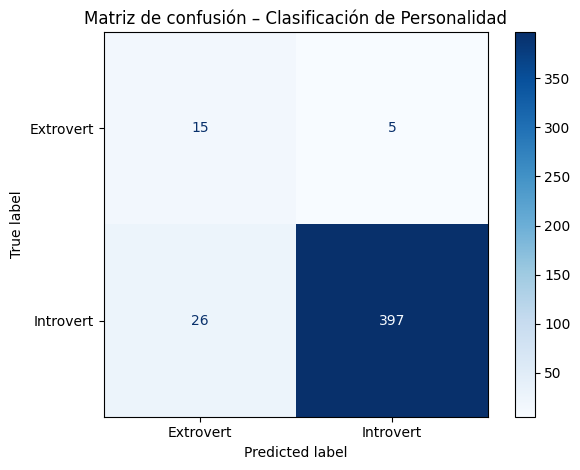

In [ ]:
# Matriz de confusión
ConfusionMatrixDisplay.from_estimator(ada, X_test, y_test, cmap="Blues")
plt.title("Matriz de confusión – Clasificación de Personalidad")
plt.tight_layout()
plt.show()


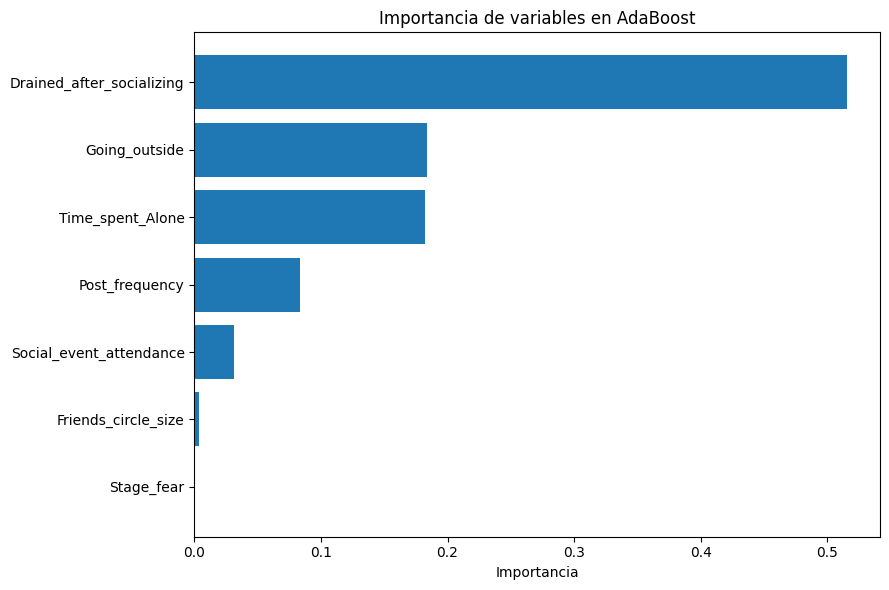

In [ ]:
# Obtener importancias y nombres
importances = ada.feature_importances_
feature_names = X_train.columns

# Crear DataFrame ordenado
imp_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

# Visualizar las 15 más importantes
plt.figure(figsize=(9, 6))
plt.barh(imp_df["Feature"][:15][::-1], imp_df["Importance"][:15][::-1])
plt.xlabel("Importancia")
plt.title("Importancia de variables en AdaBoost")
plt.tight_layout()
plt.show()

## Gradient

              precision    recall  f1-score   support

   Extrovert       0.47      0.45      0.46        20
   Introvert       0.97      0.98      0.98       423

    accuracy                           0.95       443
   macro avg       0.72      0.71      0.72       443
weighted avg       0.95      0.95      0.95       443



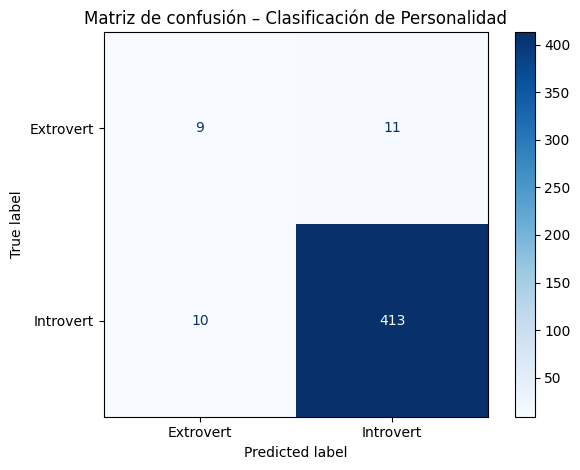

In [ ]:

# Gradient Boosting básico
gb = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)
gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)

print(classification_report(y_test, y_pred_gb))

# Matriz de confusión
ConfusionMatrixDisplay.from_estimator(gb, X_test, y_test, cmap="Blues")
plt.title("Matriz de confusión – Clasificación de Personalidad")
plt.tight_layout()
plt.show()

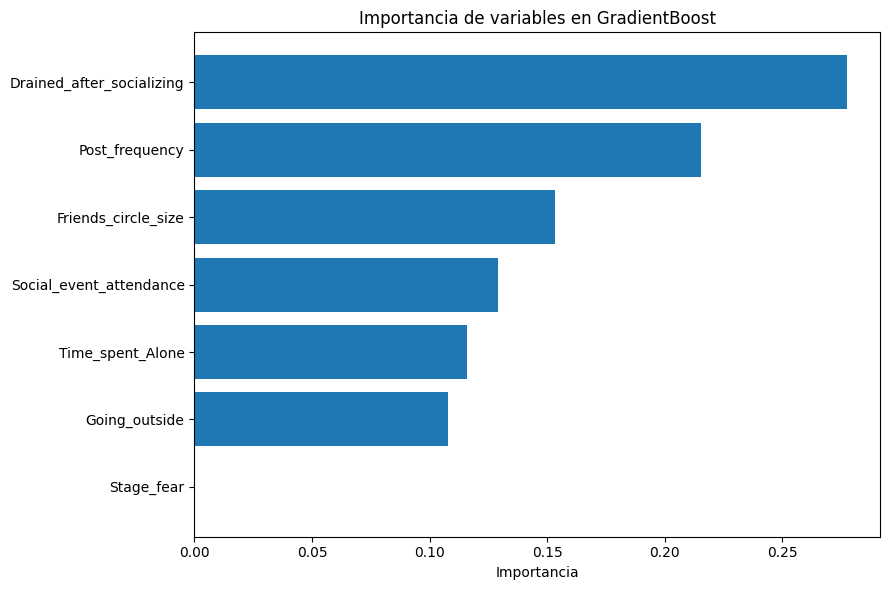

In [ ]:
# Obtener importancias y nombres
importances = gb.feature_importances_
feature_names = X_train.columns

# Crear DataFrame ordenado
imp_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

# Visualizar las 15 más importantes
plt.figure(figsize=(9, 6))
plt.barh(imp_df["Feature"][:15][::-1], imp_df["Importance"][:15][::-1])
plt.xlabel("Importancia")
plt.title("Importancia de variables en GradientBoost")
plt.tight_layout()
plt.show()

              precision    recall  f1-score   support

   Extrovert       0.37      0.80      0.51        20
   Introvert       0.99      0.94      0.96       423

    accuracy                           0.93       443
   macro avg       0.68      0.87      0.74       443
weighted avg       0.96      0.93      0.94       443



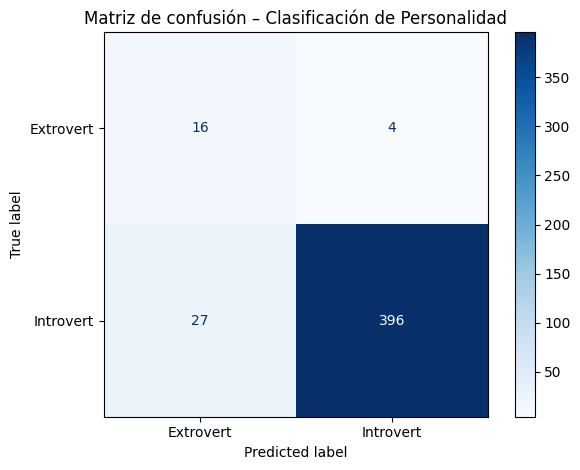

In [ ]:
# Gradient Boosting
hgb = HistGradientBoostingClassifier(
    class_weight='balanced',
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)
hgb.fit(X_train, y_train)

y_pred_gb = hgb.predict(X_test)

print(classification_report(y_test, y_pred_gb))

# Matriz de confusión
ConfusionMatrixDisplay.from_estimator(hgb, X_test, y_test, cmap="Blues")
plt.title("Matriz de confusión – Clasificación de Personalidad")
plt.tight_layout()
plt.show()

[LightGBM] [Info] Number of positive: 986, number of negative: 45
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000323 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 62
[LightGBM] [Info] Number of data points in the train set: 1031, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[

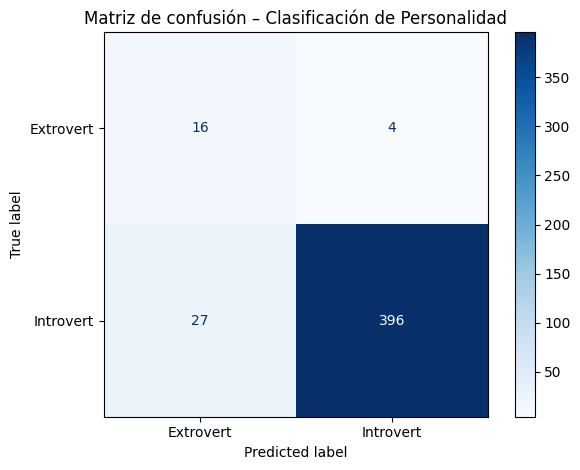

In [ ]:
# Gradient Boosting
clf = lgb.LGBMClassifier(
    class_weight='balanced',
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)
clf.fit(X_train, y_train)

y_pred_gb = clf.predict(X_test)

print(classification_report(y_test, y_pred_gb))

# Matriz de confusión
ConfusionMatrixDisplay.from_estimator(clf, X_test, y_test, cmap="Blues")
plt.title("Matriz de confusión – Clasificación de Personalidad")
plt.tight_layout()
plt.show()

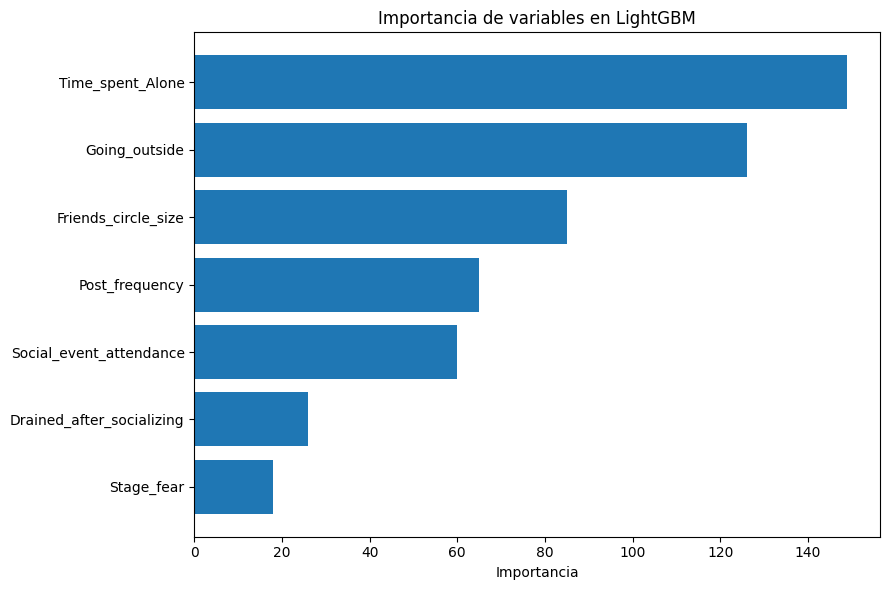

In [ ]:
# Obtener importancias y nombres
importances = clf.feature_importances_
feature_names = X_train.columns

# Crear DataFrame ordenado
imp_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

# Visualizar las 15 más importantes
plt.figure(figsize=(9, 6))
plt.barh(imp_df["Feature"][:15][::-1], imp_df["Importance"][:15][::-1])
plt.xlabel("Importancia")
plt.title("Importancia de variables en LightGBM")
plt.tight_layout()
plt.show()

Utilizar ensambles mas complejos no mejoran la predicción del modelo para este dataset en particular.

#Concluciones

Se observa que el modelo mas simple es el que predice de mejor manera la personalidad de un individuo. Puede ser que con una optimización de hiperparametros en los modelos de boosting mejore la clasificación.

Utilizar valores bajos de el numero de observaciones en cada hoja y el minimo para dividir un nodo, en este dataset fue de gran ayuda dado el desbalanceo de las clases.

Al optimizar los hyperparametros para el arbol de decisión limitar la profundidad mejoro de manera significativa la especificidad del modelo.

En la mayoria de los modelos entrenados la variable mas importante fue una variable categorica, mientras que para el modelo lightgbm fue una variable numerica. Es probable que se pueda obtener una mejor clasificación al optimizar los hyperparametros de este modelo.



# Save to html

In [ ]:
!pip --q install nbconvert

In [ ]:
!jupyter nbconvert --to html /content/Final_Activity_ModuleII.ipynb

[NbConvertApp] Converting notebook /content/Final_Activity_ModuleII.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 16 image(s).
[NbConvertApp] Writing 987334 bytes to /content/Final_Activity_ModuleII.html
